# Network Traffic Classification Pipeline

This notebook contains a full pipeline: data preprocessing, training, and evaluation for the network traffic dataset.

In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import re

## 1. Data Ingestion

In [26]:
# Load the dataset
file_path = 'Midterm_53_group.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")

Dataset shape: (394136, 7)


## 2. Preprocessing & Feature Engineering

In [27]:
df.isnull().sum()

Time           0
Source         0
No.            0
Destination    0
Protocol       0
Length         0
Info           0
dtype: int64

In [28]:
def preprocess_data(data):
    df = data.copy()
    
    # 2. Extract features from 'Info' column (e.g., ports)
    def extract_port(info):
        match = re.search(r'(\d+)\s+>\s+(\d+)', str(info))
        if match:
            return int(match.group(2)) 
        return 0
    
    df['DestPort'] = df['Info'].apply(extract_port)
    
    # 3. Filter common protocols (Target variable)
    top_protocols = df['Protocol'].value_counts().nlargest(5).index
    df['Protocol_Grouped'] = df['Protocol'].apply(lambda x: x if x in top_protocols else 'Other')
    
    # 4. Label Encoding
    le = LabelEncoder()
    df['Protocol_Target'] = le.fit_transform(df['Protocol'])
    
    # Numerical features: Time, Length, DestPort
    features = ['Time', 'Length', 'DestPort']
    X = df[features].values
    y = df['Protocol_Target'].values
    
    return X, y, le

X, y, label_encoder = preprocess_data(df)
num_classes = len(label_encoder.classes_)


In [29]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Number of classes: {num_classes} ({label_encoder.classes_})")

Training set size: (315308, 3)
Number of classes: 16 (['ARP' 'BROWSER' 'DHCP' 'DNS' 'HTTP' 'ICMP' 'ICMPv6' 'NBNS' 'OCSP' 'RARP'
 'SSLv2' 'STUN' 'TCP' 'TLSv1' 'TLSv1.2' 'TLSv1.3'])


## 3. TensorFlow Data Pipeline

In [30]:
def create_dataset(X, y, batch_size=64, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000)
    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(X_train, y_train)
test_ds = create_dataset(X_test, y_test, shuffle=False)

## 4. Model Training

In [33]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,             
    restore_best_weights=True
)

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds, 
    validation_data=test_ds, 
    epochs=100,              
    callbacks=[early_stop]   
)

Epoch 1/100
4927/4927 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9501 - loss: 0.1905 - val_accuracy: 0.9773 - val_loss: 0.0955
Epoch 2/100
4927/4927 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9764 - loss: 0.0928 - val_accuracy: 0.9777 - val_loss: 0.0841
Epoch 3/100
4927/4927 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9768 - loss: 0.0877 - val_accuracy: 0.9780 - val_loss: 0.0805
Epoch 4/100
4927/4927 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9769 - loss: 0.0860 - val_accuracy: 0.9783 - val_loss: 0.0792
Epoch 5/100
4927/4927 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9771 - loss: 0.0849 - val_accuracy: 0.9779 - val_loss: 0.0795
Epoch 6/100
4927/4927 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9771 - loss: 0.0843 - val_accuracy: 0.9783 - val_loss: 0.0782
Epoch 7/100
4927/4927 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9771 - loss: 0.0837 - val_accuracy: 0.9771 - val_loss: 0.0817
Epoch 8/100
4927/4927 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9771 - loss: 0

## 5. Evaluation

1232/1232 ━━━━━━━━━━━━━━━━━━━━ 1s 913us/step - accuracy: 0.9783 - loss: 0.0782
Test Loss: 0.0782
Test Accuracy: 0.9783


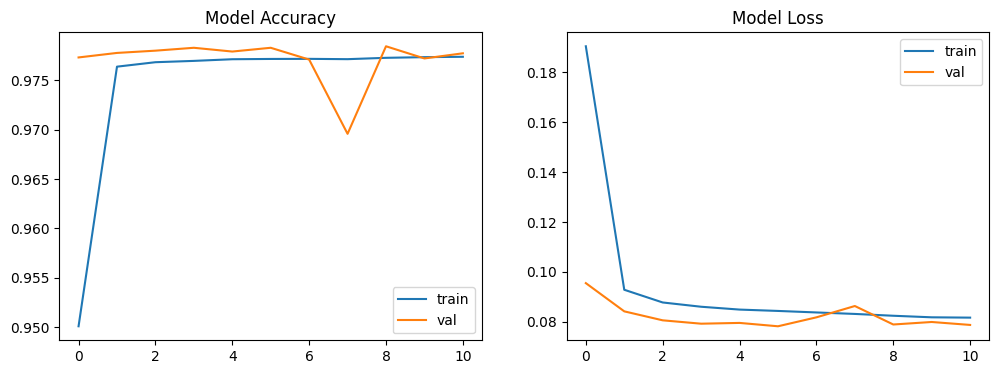

In [34]:
# Evaluate on test data
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Model Loss')
plt.legend()
plt.show()

In [39]:
# Sample Prediction
sample_idx = 0
sample_input = X_test[sample_idx:sample_idx+1]
prediction = model.predict(sample_input)
predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
true_label = label_encoder.inverse_transform([y_test[sample_idx]])

print(f"Sample Input Index 0")
print(f"Predicted Protocol: {predicted_label[0]}, True Protocol: {true_label[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Sample Input Index 0
Predicted Protocol: TCP, True Protocol: TCP
